In [1]:
import random 
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    make_scorer,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    precision_score,
    average_precision_score,
    recall_score,
    f1_score,
    roc_curve,
    precision_recall_curve
)

from sklearn.inspection import permutation_importance, PartialDependenceDisplay

import torch
from torch_geometric.data import HeteroData
import torch
import torch.nn.functional as F
from torch_geometric.data import HeteroData
import torch_geometric.transforms as T
from torch_geometric.nn import SAGEConv, to_hetero

/Users/glouno/sourceCode/DALAS-Project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
with open("../data/03-result/merged_df.pkl","rb") as f:
    merged_df =pickle.load(f)
with open("../data/03-result/drugs_df.pkl","rb") as f:
    drugs_df =pickle.load(f)
with open("../data/03-result/diseases_df.pkl","rb") as f:
    diseases_df =pickle.load(f)
with open("../data/02-result/dates_df.pkl","rb") as f:
    dates_df =pickle.load(f)

In [3]:
FIG_PATH = "../results/figures/04-"
TAB_PATH = "../results/tables/04-"
MODEL_PATH = "../results/models/"

# LaTeX-friendly settings
plt.rcParams.update({
    # "text.usetex": True,      
    "font.size": 10,           
    "axes.labelsize": 10,
    "xtick.labelsize": 8,     
    "ytick.labelsize": 8,
    "legend.fontsize": 9,
    "lines.linewidth": 1
})
plt.rcParams["figure.figsize"] = (8, 6)

In [4]:
# TODO: ATTENTION, this flag means "Has a therapeutic application, opposed to e.g. imaging"
# think about whether to keep it
# merged_df = merged_df[merged_df["therapeutic_flag"]]
# drugs_df = drugs_df[drugs_df["therapeutic_flag"]]

# Prepare train and test set

In [5]:
SPLIT_BY_TIME = True # do split by time only
TRAIN_SIZE = 0.85

if SPLIT_BY_TIME:
    merged_df = (merged_df
    .merge(dates_df[["drug_id","disease_id", "first_trial_date"]], how="left", on=["drug_id","disease_id"])
    .sort_values(by="first_trial_date")
    .reset_index(drop=True)
    )
    
    print("Split date is:", merged_df["first_trial_date"][int(merged_df.shape[0]*0.9)])

    merged_df = merged_df.drop(columns=["first_trial_date"])

    FIG_PATH += "time_split-"
    TAB_PATH += "time_split-"
    MODEL_PATH += "time_split-"
else:
    merged_df = merged_df.reset_index(drop=True)
    FIG_PATH += "random_split-"
    TAB_PATH += "random_split-"
    MODEL_PATH += "random_split-"


Split date is: 2014-08-12


In [6]:
X = merged_df.drop(columns=["success", "drug_id","disease_id", "drug_name", "disease_name"])
y = merged_df["success"]

num_cols = X.select_dtypes(include=["float64", "int64"]).columns
cat_cols = X.select_dtypes(include=["object", "category"]).columns

indices = np.arange(len(y))

if SPLIT_BY_TIME:
    n_samples = len(X)
    n_train = int(n_samples * TRAIN_SIZE )

    TRAIN_IDX, TEST_IDX  = indices[:n_train], indices[n_train:]

else:
    
    TRAIN_IDX, TEST_IDX = train_test_split(
    indices, test_size=1-TRAIN_SIZE, random_state=42, stratify=y
    )

X_train, X_test = X.iloc[TRAIN_IDX], X.iloc[TEST_IDX]
y_train, y_test = y.iloc[TRAIN_IDX], y.iloc[TEST_IDX]


# Preprocessor

In [7]:
# NOTE: normally imputation is already done in previous steps
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

# Models definition

In [8]:
SCORE = make_scorer(f1_score, pos_label=1) 
# 1 is expected to be minority class, need to balance classes where possible
ratio = np.sum(y_train == 0) / np.sum(y_train == 1)

# KNN =================================================================================
knn_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("knn", KNeighborsClassifier(n_neighbors=20))
])

knn_param_grid = {
    "knn__n_neighbors": [5, 10, 20, 30],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2]  # Manhattan vs Euclidean
}

knn_cv = GridSearchCV(knn_model, knn_param_grid, cv=5, scoring=SCORE, n_jobs=-1)

# Logistic Regression =====================================================================
logreg_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("logreg", LogisticRegression(class_weight='balanced', solver="saga", max_iter=500))
])

logreg_param_grid = [
    # {
    #     "logreg__penalty": ["l1"],
    #     "logreg__C": [0.01, 0.1, 1, 10, 100],
    #     "logreg__l1_ratio": [None]  
    # },
    # {
    #     "logreg__penalty": ["l2"],
    #     "logreg__C": [0.01, 0.1, 1, 10, 100],
    #     "logreg__l1_ratio": [None]  
    # },
    {
        "logreg__C": [0.01, 0.1, 1, 10, 100],
        "logreg__l1_ratio": [0, 0.25, 0.5, 0.75, 1]
    }
]

logreg_cv = GridSearchCV(logreg_model, logreg_param_grid, cv=5, scoring=SCORE, n_jobs=-1)


# Linear SVM =================================================================================

svm_model = Pipeline([
    ("preprocess", preprocessor),
    ("svm", SVC(class_weight='balanced'))
    ])

svm_param_grid = [
    {
        "svm__kernel": ["linear"],
        "svm__C": [0.01, 0.1, 1, 10]
    },
    {
        "svm__kernel": ["poly"],
        "svm__C": [0.1, 1, 10],
        "svm__degree": [2, 3, 4],
        "svm__gamma": ["scale", "auto"]
    },
    {
        "svm__kernel": ["rbf"],
        "svm__C": [0.1, 1, 10],
        "svm__gamma": ["scale", "auto"]
    }
]

svm_cv = GridSearchCV(svm_model, svm_param_grid, cv=5, scoring=SCORE, n_jobs=-1)

# Random Forest =============================================================================
rf_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("rf", RandomForestClassifier(class_weight='balanced',n_estimators=300))
])
rf_param_grid = {
    "rf__n_estimators": [100, 300, 500],
    "rf__max_depth": [None, 10, 20],
    "rf__min_samples_split": [2, 5],
    "rf__min_samples_leaf": [1, 2]
}

rf_cv = GridSearchCV(rf_model, rf_param_grid, cv=5, scoring=SCORE, n_jobs=-1)

# Gradient Boosting ==========================================================================

gb_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("gb", GradientBoostingClassifier(n_estimators=300, max_depth=3, learning_rate=0.05))
])

gb_param_grid = {
    "gb__n_estimators": [100, 300],
    "gb__max_depth": [3, 5],
    "gb__learning_rate": [0.01, 0.05, 0.1],
    "gb__subsample": [0.8, 1.0]
}

gb_cv = GridSearchCV(gb_model, gb_param_grid, cv=5, scoring=SCORE, n_jobs=-1)

# XGBoost ==========================================================================


xgb_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("xgb", XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        use_label_encoder=False,
        scale_pos_weight= ratio
    ))
])

xgb_param_grid = {
    "xgb__n_estimators": [100, 300],
    "xgb__max_depth": [3, 5],
    "xgb__learning_rate": [0.01, 0.05, 0.1],
    "xgb__subsample": [0.8, 1.0],
    "xgb__colsample_bytree": [0.8, 1.0], 
    "xgb__gamma": [0, 0.1]  
}

xgb_cv = GridSearchCV(xgb_model, xgb_param_grid, cv=5, scoring=SCORE, n_jobs=-1)

# All models =======================================================================================
model_cvs = (
    knn_cv,
    logreg_cv,
    svm_cv,
    rf_cv,
    gb_cv,
    xgb_cv
)

full_names = {
    "knn": "k-Nearest Neighbors",
    "logreg": "Logistic Regression",
    "svm": "Support Vector Machine",
    "rf": "Random Forest",
    "gb": "Gradient Boost",
    "xgb" : "XGBoost"
}

# Tune hyperparameters and select models with CV

In [9]:
RUN_TUNING = False

if RUN_TUNING:
    summary_df = pd.DataFrame()
    models = {}
    for model_cv in model_cvs:
        model_cv.fit(X_train, y_train)
        # NOTE: best estimator is trained on the whole train dataset
        model = model_cv.best_estimator_ 
        model_name = list(model.named_steps.keys())[1]
        models[model_name] = model

        cv_df = pd.DataFrame(model_cv.cv_results_)[['params', 'mean_test_score', 'std_test_score']]
        cv_df = cv_df[cv_df["mean_test_score"] == cv_df["mean_test_score"].max() ]

        model.fit(X_train, y_train)

        summary_row = pd.DataFrame([{"model" : list(model.named_steps.keys())[1]}])
        summary_row.reset_index(drop=True, inplace=True)
        cv_df.reset_index(drop=True, inplace=True)
        summary_row = pd.concat([summary_row, cv_df], axis=1)
        summary_df = pd.concat([summary_df, summary_row], axis=0)
    summary_df.reset_index(drop=True, inplace=True)
    with open(MODEL_PATH + "summary_df.pkl","wb") as f:
            pickle.dump(summary_df,f)
    with open(MODEL_PATH + "models.pkl","wb") as f:
        pickle.dump(models,f)
else:
    with open(MODEL_PATH + "summary_df.pkl","rb") as f:
        summary_df =pickle.load(f)
    with open(MODEL_PATH + "models.pkl","rb") as f:
        models =pickle.load(f)
    

In [10]:
# NOTE: attention to data leak, one must not choose the model based on test set
# performance - it's cheating
pretty_summary = summary_df.sort_values(by="mean_test_score", ascending=False).dropna()
pretty_summary["params"] = pretty_summary["params"].apply( lambda params: ",".join([f"{k.split('__')[1]} = {v}" for k, v in params.items()]))
pretty_summary["model"] = pretty_summary["model"].map(full_names)
pretty_summary["params"] = pretty_summary["params"].str.replace("_", r"\_", regex=False)
pretty_summary = pretty_summary.rename( columns = {"model": "\\textbf{Model}","params":"\\textbf{Best parameters}" ,"mean_test_score" : "\\textbf{Mean F1 score}", "std_test_score": "\\textbf{Std F1 score}"})


pretty_summary.iloc[:,[0,2,3]].to_latex(TAB_PATH + "model_comparison.tex",index=False, 
                                        longtable=False, 
                                        escape=False)

pretty_summary.iloc[:,[0,1]].to_latex(TAB_PATH + "best_parameters.tex", index=False, 
                                      longtable=False, escape=False, 
                                      column_format="p{4cm} p{10cm}")

# pretty_summary.to_latex(TAB_PATH + "model_comparison.tex", index=False, longtable=False, escape=True)
pretty_summary

,\textbf{Model},\textbf{Best parameters},\textbf{Mean F1 score},\textbf{Std F1 score}
10,XGBoost,"colsample\_bytree = 0.8,gamma = 0,learning\_ra...",0.642752,0.055461
1,Logistic Regression,"C = 0.1,l1\_ratio = 0",0.624640,0.030290
6,Support Vector Machine,"C = 1,degree = 2,gamma = scale,kernel = poly",0.619498,0.034367
9,Gradient Boost,"learning\_rate = 0.05,max\_depth = 3,n\_estima...",0.611923,0.069881
8,Random Forest,"max\_depth = 10,min\_samples\_leaf = 2,min\_sa...",0.592670,0.028305
0,k-Nearest Neighbors,"n\_neighbors = 5,p = 2,weights = distance",0.581064,0.064035


# Visualize evaluation

- TODO: balanced_accuracy score
- TODO: see wikipedian evalution metrics forbinary classification
- TODO: check imbalanced_learn module 

XGBoost


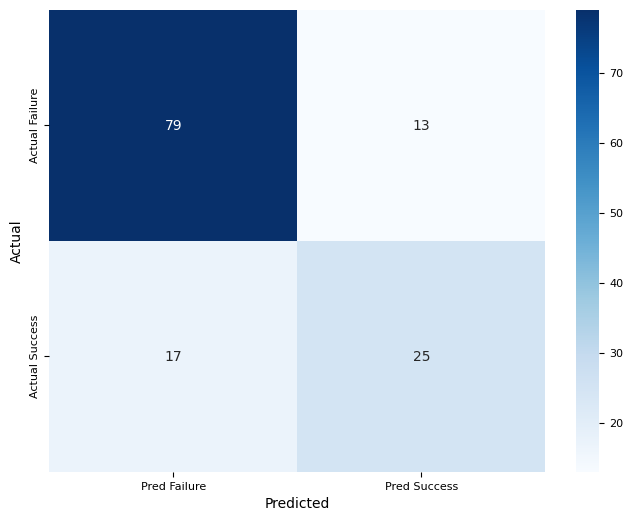

In [11]:
best_models = summary_df.sort_values(by="mean_test_score", ascending=False).reset_index(drop=True)["model"]
MODEL_NAME = best_models[0]

print(full_names[MODEL_NAME])

if not MODEL_NAME in models:
    raise KeyError("This model wan't fine tuned")

model = models[MODEL_NAME]
y_pred = model.predict(X_test)

if hasattr(model, "predict_proba") and callable(getattr(model, "predict_proba")):
    y_proba = model.predict_proba(X_test)[:, 1]
else:
    print("This model doesn't yeild probabilities")
    y_proba = None
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Pred Failure', 'Pred Success'],
            yticklabels=['Actual Failure', 'Actual Success'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
# plt.title('Confusion Matrix - Clinical Trial Prediction')
plt.savefig(FIG_PATH+MODEL_NAME+"-confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

  Accuracy: 0.7761194029850746
  Precision: 0.6578947368421053
  Recall: 0.5952380952380952
  F1 score: 0.625


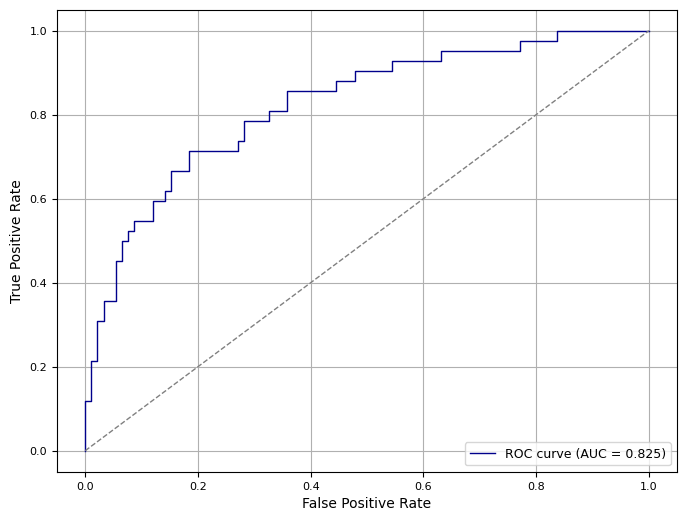

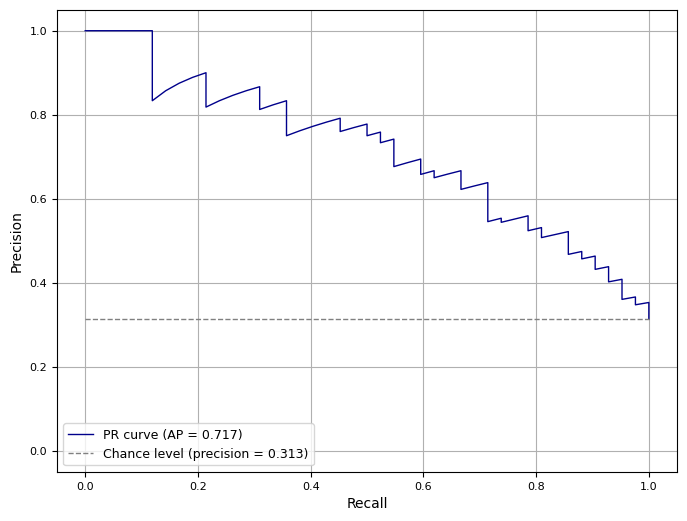

In [12]:
print("  Accuracy:", accuracy_score(y_test, y_pred))
print("  Precision:", precision_score(y_test, y_pred))
print("  Recall:", recall_score(y_test, y_pred))
print("  F1 score:", f1_score(y_test, y_pred))
if y_proba is not None:
    auc = roc_auc_score(y_test, y_proba)
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    plt.figure()
    plt.plot(fpr, tpr, color='darkblue', label=f'ROC curve (AUC = {auc:.3f})')
    plt.plot([0,1], [0,1], color='gray', linestyle='--')  # diagonal line
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    # plt.title('Receiver Operating Characteristic')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.savefig(FIG_PATH+ MODEL_NAME+"-roc.png", dpi=300, bbox_inches="tight")
    plt.show()

    ap = average_precision_score(y_test, y_proba)
    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

    pos_rate = y_test.mean() 
    plt.figure()
    plt.plot(
        recall,
        precision,
        color="darkblue",
        label=f"PR curve (AP = {ap:.3f})"
    )
    plt.hlines(
    y=pos_rate,
    xmin=0,
    xmax=1,
    colors="gray",
    linestyles="--",
    label=f"Chance level (precision = {pos_rate:.3f})"
)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.ylim([-0.05,1.05])
    # plt.title("Precision-Recall Curve")
    plt.legend(loc="lower left")
    plt.grid(True)
  
    plt.savefig(FIG_PATH+ MODEL_NAME+"-pr.png", dpi=300, bbox_inches="tight")
    plt.show()

# Feature importance

## Model agnostic feature importance

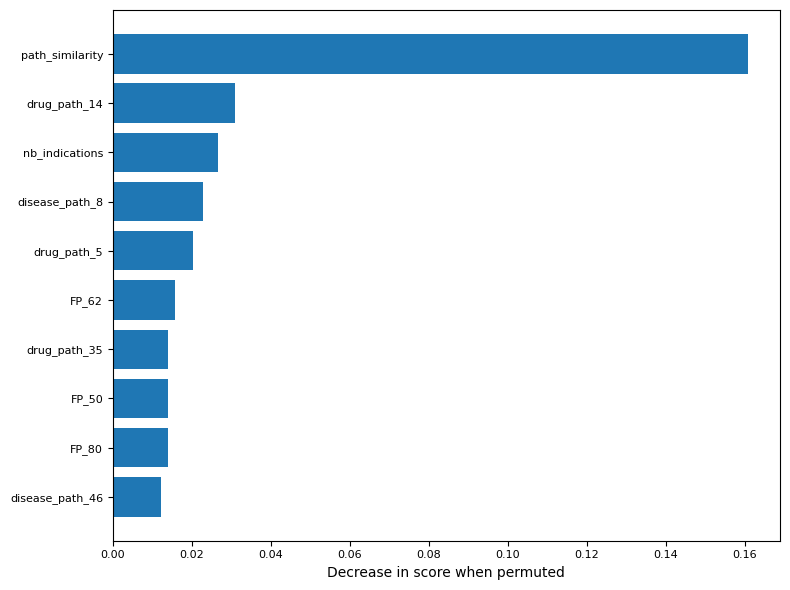

In [14]:
random.seed(1)
np.random.seed(1)
perm_imp = permutation_importance(estimator=model, X=X_test, y=y_test, n_repeats=10, scoring=SCORE)

# Compute a dataframe to sum up the results
perm_importances = pd.DataFrame({
    "feature" : X.columns,
    "mean_importance" : perm_imp["importances_mean"],
    "std_importance" : perm_imp["importances_std"]
})
perm_importances.sort_values(by="mean_importance", ascending=False, inplace=True, ignore_index=True)
plt.figure()
plt.barh(perm_importances["feature"][:10][::-1], perm_importances["mean_importance"][:10][::-1])
plt.xlabel("Decrease in score when permuted")
# plt.title("Permutation importance")
plt.tight_layout()
plt.savefig(FIG_PATH+ MODEL_NAME +"-perm_importance.png", dpi=300, bbox_inches="tight")
plt.show()

/Users/glouno/sourceCode/DALAS-Project/.venv/lib/python3.11/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning: The column 194 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


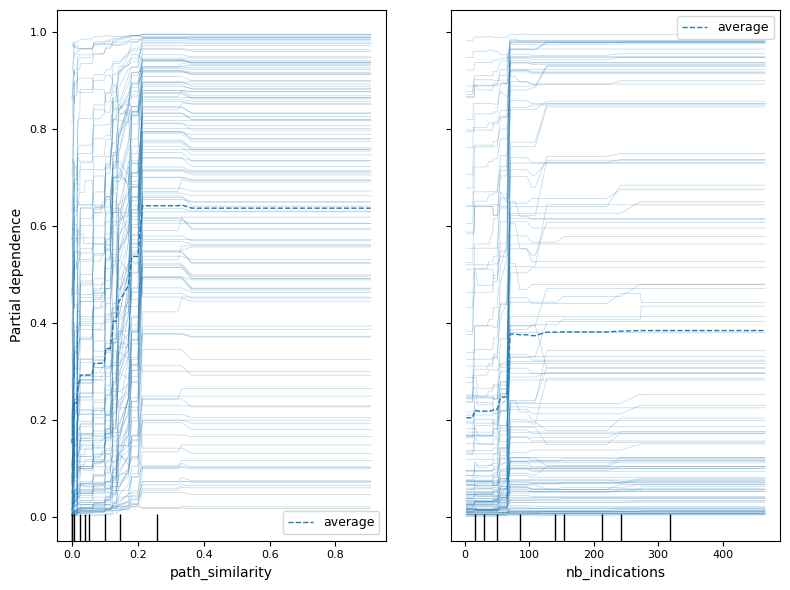

/Users/glouno/sourceCode/DALAS-Project/.venv/lib/python3.11/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning: The column 194 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


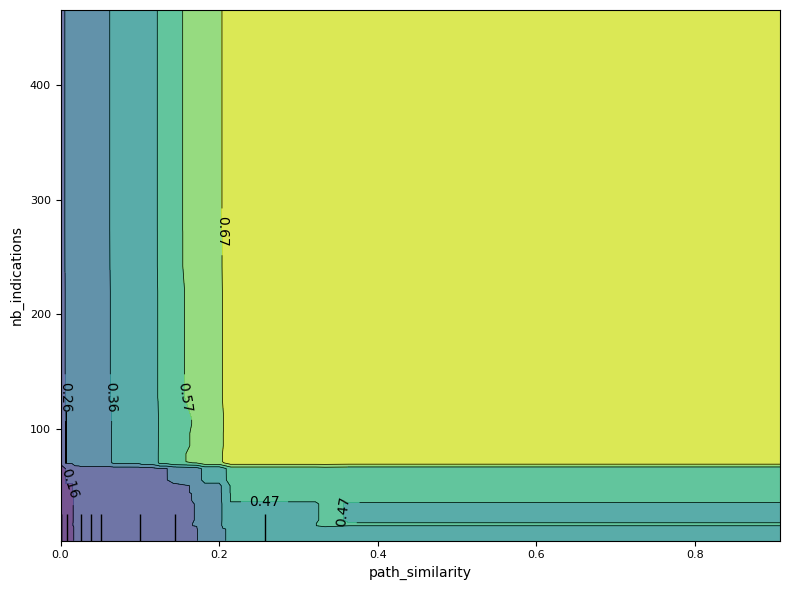

In [15]:
DO_2D_PDD = True # can be slow 

feature_to_plot = ["path_similarity", "nb_indications"]
try:
    if not feature_to_plot:
        feature_to_plot = perm_importances["feature"][:3].tolist()
    target_class = 1                        

    PartialDependenceDisplay.from_estimator(
        estimator=model,
        X = X_test,
        target=target_class,
        features = feature_to_plot,
        kind="both"
    )
    plt.tight_layout()
    plt.savefig(FIG_PATH+ MODEL_NAME +"-1d_partial_dependence.png", dpi=300, bbox_inches="tight")
    plt.show()

    if DO_2D_PDD:

        if not feature_to_plot:
            features_2d = [tuple(perm_importances["feature"][:2])]
        else:
            features_2d = [tuple(feature_to_plot)]
        
        PartialDependenceDisplay.from_estimator(
            estimator=model,
            X = X_test,
            target=target_class,
            features=features_2d
        )
        plt.tight_layout()
        plt.savefig(FIG_PATH+ MODEL_NAME +"-2d_partial_dependence.png", dpi=300, bbox_inches="tight")
        plt.show()
except ValueError:
    print("Cannot use this estimator for PD plot")

# Analysis of success and failure cases

In [16]:
cases_df = X_test.loc[:,~X_test.columns.str.contains(r"drug_path|disease_path|FP")].copy()

cases_df["y_true"] = y_test
cases_df["y_pred"] = y_pred
cases_df["y_proba"] = y_proba
cases_df["correct"] = cases_df.y_true == cases_df.y_pred

cases_df["TP"] = (cases_df.y_true == 1) & (cases_df.y_pred == 1)
cases_df["TN"] = (cases_df.y_true == 0) & (cases_df.y_pred == 0)
cases_df["FP"] = (cases_df.y_true == 0) & (cases_df.y_pred == 1)
cases_df["FN"] = (cases_df.y_true == 1) & (cases_df.y_pred == 0)

cases_df["case"] = np.select(
    [cases_df.TP, cases_df.TN,cases_df.FP, cases_df.FN],
    ["TP", "TN", "FP", "FN"],
    default="UNDEFINED"
)

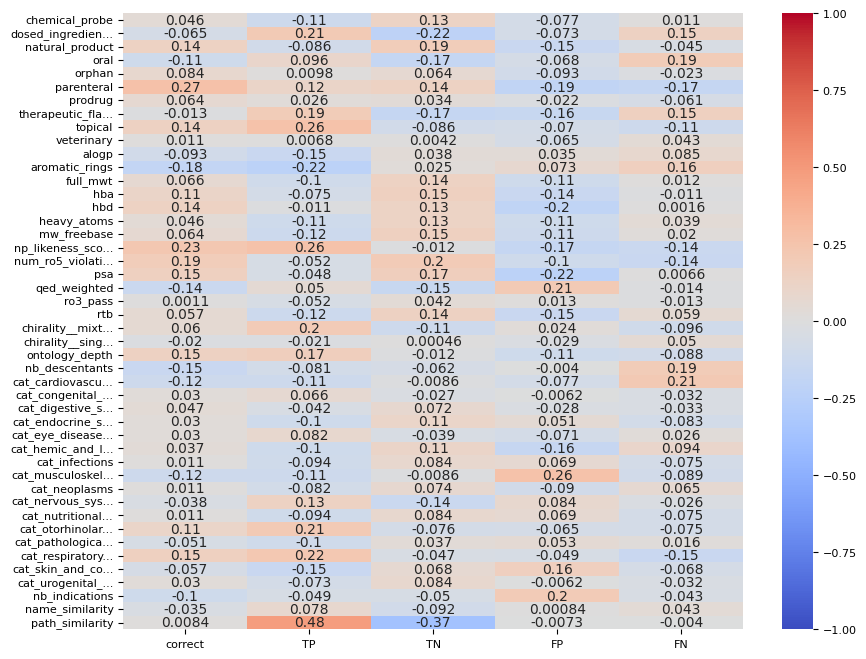

In [17]:
plt.figure(figsize=(10,8))
max_len = 15
corr = cases_df.select_dtypes(["number", "bool"]).corr().iloc[:-8,-5:].dropna(axis=0)
cropped_labels = [label if len(label) <= max_len else label[:max_len] + "..." for label in corr.index]
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1, annot=True, yticklabels=cropped_labels)
# plt.xticks([])

plt.savefig(FIG_PATH+"xgb-corr_matrix-confusion.png", dpi=300, bbox_inches="tight")

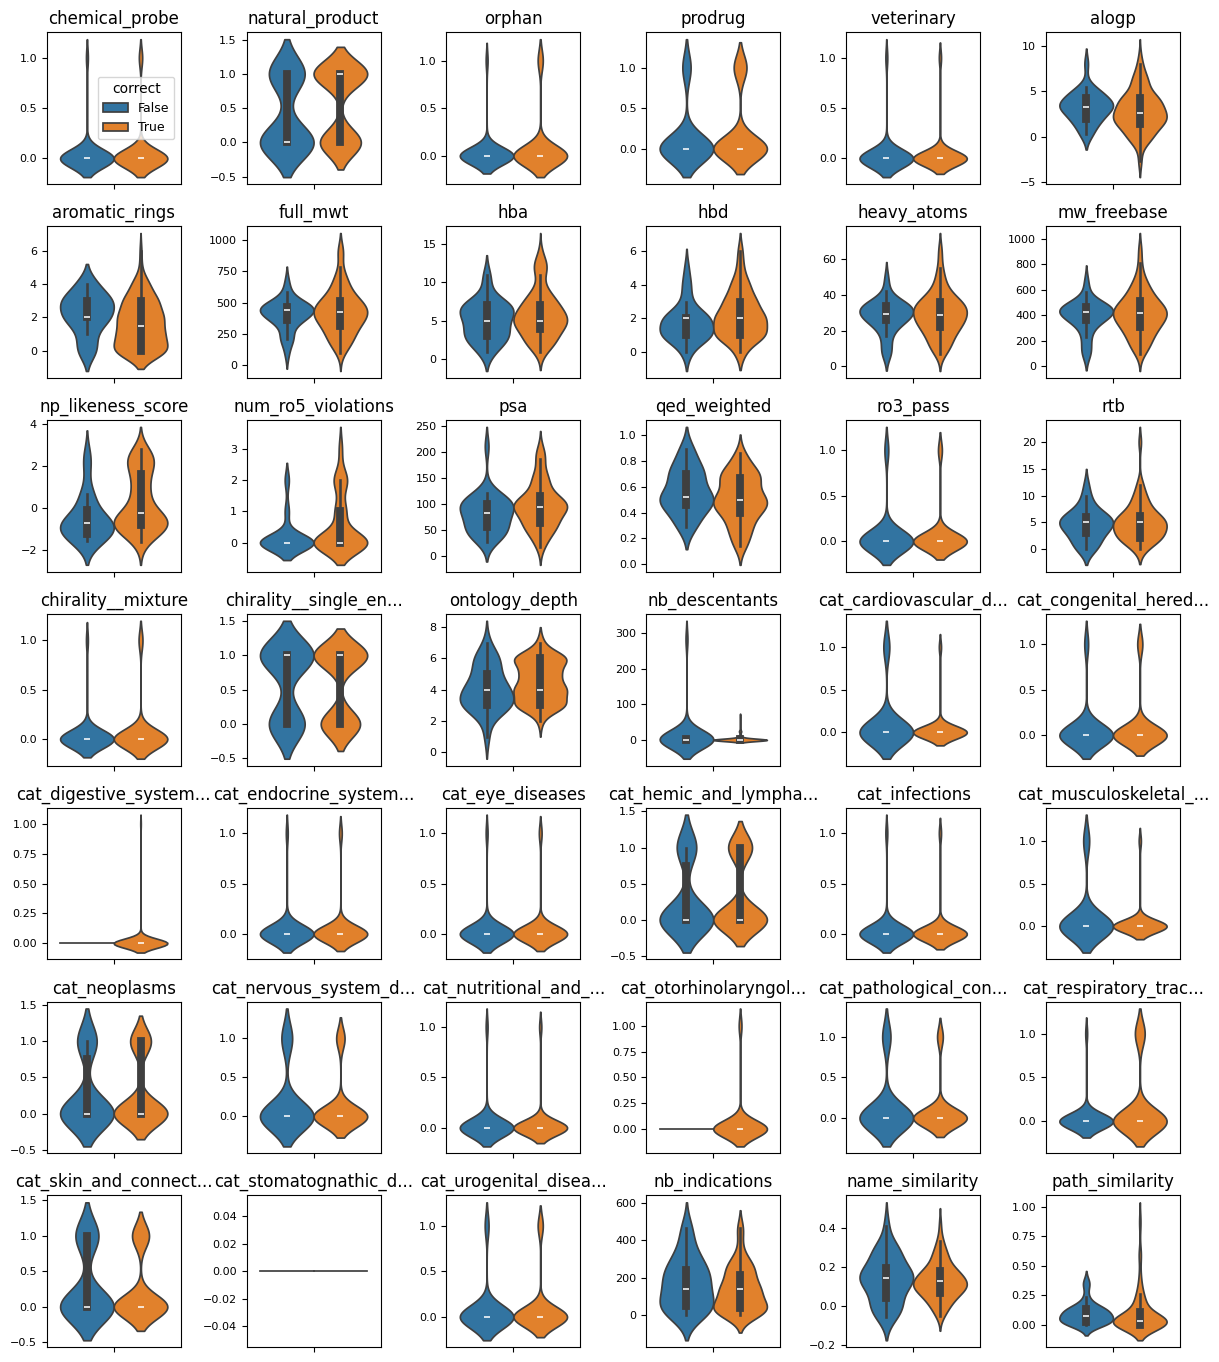

In [18]:
prefix_not_interpretable = ("FP", "drug_path", "disease_path") 
num_features = cases_df.select_dtypes(include=np.number).columns[:-2]

n_cols = 6  # number of plots per row
n_rows = (len(num_features) + n_cols - 1) // n_cols 
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2*n_cols, 2*n_rows))
axes = axes.flatten()  # flatten in case of multiple rows

max_len = 20
for i, col in enumerate(num_features[~num_features.str.startswith(prefix_not_interpretable)]):
    sns.violinplot(y=cases_df[col], ax = axes[i], hue=cases_df["correct"]);
    axes[i].set_title(col if len(col) <= max_len else col[:max_len] + "..." )
    axes[i].set_ylabel(None)
    if i != 0:
        axes[i].get_legend().remove()
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Create one single legend for all subplots
# handles, labels = axes[i].get_legend_handles_labels()  # use first subplot
# fig.legend(handles, labels, loc='lower right', ncol=len(labels), frameon=True, fancybox=True)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(FIG_PATH+"xgb-feature_distribution_by_correct", dpi=300, bbox_inches="tight")
plt.show()

## Model-specific feature importance

In [19]:
num_features = list(num_cols)
cat_features = list(cat_cols)
all_features = num_features + cat_features

if "rf" in model.named_steps:
    rf = model.named_steps["rf"]

    
    importances = rf.feature_importances_
    rf_feature_importance = pd.DataFrame({
        "feature": all_features,
        "importance": importances
    }).sort_values(by="importance", ascending=False)
    print(rf_feature_importance)
elif "logreg" in model.named_steps:
    logreg = model.named_steps["logreg"]
    coef = logreg.coef_[0]  
    logreg_feature_importance = pd.DataFrame({
        "feature": all_features,
        "coef": coef,
        "abs_coef": np.abs(coef)
    }).sort_values(by="abs_coef", ascending=False)

    print(logreg_feature_importance)

# TODO: PU / semi-supervized models 
# TODO: node2vec to generate features

# Heterogenous Graph Model

https://pytorch-geometric.readthedocs.io/en/2.6.0/notes/heterogeneous.html

Example schema:

```py
HeteroData(
  paper={
    x=[736389, 128],
    y=[736389],
    train_mask=[736389],
    val_mask=[736389],
    test_mask=[736389]
  },
  author={ x=[1134649, 128] },
  institution={ x=[8740, 128] },
  field_of_study={ x=[59965, 128] },
  (author, affiliated_with, institution)={ edge_index=[2, 1043998] },
  (author, writes, paper)={ edge_index=[2, 7145660] },
  (paper, cites, paper)={ edge_index=[2, 5416271] },
  (paper, has_topic, field_of_study)={ edge_index=[2, 7505078] }
)
```

Take data from:

- unique pathways from `drugs_df["drug_pathways"]`, `diseases_df["disease_pathways"]`
    - →  **pathway nodes**

- `drugs_df` 
    - →  **drug nodes**
    - →  feature vector: from `FP_...` and other non-path columns
    - →  **edges drug-pathway** from lists `drug_pathways`
    
- `diseases_df` 
    - →  **disease nodes**
    - →  feature vector: from non-path columns (probably none)
    - →  **edges disese-pathway** from lists `disease_pathways`

- `merged_df` 
    - →  **edges drug-disease** labeled by `success`

Nodes:

In [20]:
drugs_df = drugs_df.reset_index(drop=True)
diseases_df = diseases_df.reset_index(drop=True)
merged_df = merged_df.reset_index(drop=True)

In [ ]:
drug_features = drugs_df.drop(columns = drugs_df.filter(regex="path").columns)
drug_features = drug_features.select_dtypes(include=["number", "bool"])
drug_features = torch.tensor( drug_features.values.astype(np.float64), dtype=torch.float, device="cpu")

disease_features = diseases_df.drop(columns = diseases_df.filter(regex="path").columns)
disease_features = disease_features.select_dtypes(include=["number", "bool"])
disease_features = torch.tensor( disease_features.values.astype(np.float64), dtype=torch.float, device="cpu")

all_pathways = np.array( list(set(drugs_df["drug_pathways"].explode()) | set(diseases_df["disease_pathways"].explode())), dtype=str)

Keep track of ROW ids:

In [ ]:
path2id = {p: i for i, p in enumerate(all_pathways)}
drug2id = {row["drug_id"]:i for i, row in drugs_df.iterrows()}
disease2id = {row["disease_id"]:i for i, row in diseases_df.iterrows()}

Edges:

In [ ]:
drug_pathway_edges = []
for _, row in drugs_df.iterrows():
    for path in row["drug_pathways"]:
        drug_id = drug2id[row["drug_id"]]
        path_id = path2id[path]
        drug_pathway_edges.append([drug_id, path_id])

drug_pathway_edges = torch.tensor(drug_pathway_edges, dtype=torch.long, device="cpu").t().contiguous()

disease_pathway_edges = []
for _, row in diseases_df.iterrows():
    for path in row["disease_pathways"]:
        disease_id = disease2id[row["disease_id"]]
        path_id = path2id[path]
        disease_pathway_edges.append([disease_id, path_id])

disease_pathway_edges = torch.tensor(disease_pathway_edges, dtype=torch.long, device="cpu").t().contiguous()

In [ ]:
drug_disease_edges = []
drug_disease_edge_label = []

for _, row in merged_df.iterrows():
    drug_id = drug2id[row["drug_id"]]
    disease_id = disease2id[row["disease_id"]]
    drug_disease_edges.append([drug_id, disease_id])
    drug_disease_edge_label.append(int(row["success"]))


drug_disease_edges = torch.tensor(drug_disease_edges, dtype=torch.long, device="cpu").t().contiguous()

drug_disease_edge_label = torch.tensor(drug_disease_edge_label, dtype=torch.float)



Build the graph:

In [ ]:
num_drugs = len(drugs_df)
num_diseases = len(diseases_df)
num_pathways = len(all_pathways)
num_trials = len(merged_df)

In [ ]:
data = HeteroData()


data["drug"].x = drug_features
data["disease"].x = disease_features 
data["pathway"].x = torch.ones( (num_pathways, 1)) # dummy features

data['drug', 'interacts', 'pathway'].edge_index = drug_pathway_edges
data['disease', 'associated_with', 'pathway'].edge_index = disease_pathway_edges
data['drug', 'tryed_against', 'disease'].edge_index = drug_disease_edges
data['drug', 'tryed_against', 'disease'].edge_label = drug_disease_edge_label

data


In [ ]:
print(data.__repr__())

### GNN edge-level prediction

In [ ]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Ensures that the CUDA convolution operations are deterministic
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

#### Preprocessing:

In [ ]:
# We need to add reverse edges for the auxiliary types so messages flow 
# bi-directionally (e.g. Pathway -> Drug).
# We EXCLUDE the target edge type ('tryed_against') from message passing 
# to prevent data leakage (predicting label using the label itself).
transform = T.AddMetaPaths(
    metapaths=[
        [('drug', 'interacts', 'pathway'), ('pathway', 'rev_interacts', 'drug')],
        [('disease', 'associated_with', 'pathway'), ('pathway', 'rev_associated_with', 'disease')]
    ],
    drop_orig_edge_types=False, # Keep original edges
    drop_unconnected_node_types=False
)
# Note: For simplicity in this minimal example, we will manually add reverse edges below
# instead of complex transforms to keep it readable.

# Simple manual reverse edge addition for message passing:
data['pathway', 'rev_interacts', 'drug'].edge_index = data['drug', 'interacts', 'pathway'].edge_index.flip([0])
data['pathway', 'rev_associated', 'disease'].edge_index = data['disease', 'associated_with', 'pathway'].edge_index.flip([0])

#### Model:

In [ ]:
class GNN(torch.nn.Module):
    def __init__(self, hidden_channels, out_channels):
        super().__init__()
        # SAGEConv is general purpose. -1 lets PyG infer input dimensions.
        self.conv1 = SAGEConv((-1, -1), hidden_channels)
        self.conv2 = SAGEConv((-1, -1), out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index)
        return x

class LinkClassifier(torch.nn.Module):
    def __init__(self, metadata, hidden_channels, out_channels):
        super().__init__()
        self.gnn = GNN(hidden_channels, out_channels)
        # Convert GNN to HeteroGNN (automatically handles different node/edge types)
        self.gnn = to_hetero(self.gnn, metadata, aggr='sum')
        
        # Final classifier: Concatenate Drug + Disease embeddings -> Probability
        self.classifier = torch.nn.Linear(out_channels * 2, 1)

    def forward(self, data):
        # 1. Message Passing: Get embeddings for all nodes
        # We only pass the message passing edges, NOT the target edges
        x_dict = self.gnn(data.x_dict, data.edge_index_dict)
        
        # 2. Edge Prediction
        # Get embeddings for the source (drug) and target (disease) of the trials
        edge_index = data['drug', 'tryed_against', 'disease'].edge_index
        src, dst = edge_index
        
        feat_drug = x_dict['drug'][src]
        feat_disease = x_dict['disease'][dst]
        
        # Concatenate and classify
        x = torch.cat([feat_drug, feat_disease], dim=-1)
        return self.classifier(x).squeeze()

#### Training loop:

In [ ]:
N_EPOCHS = 100

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)
model = LinkClassifier(data.metadata(), hidden_channels=32, out_channels=16).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


# Calculate weights based on training labels - to handle class imbalance
labels = data['drug', 'tryed_against', 'disease'].edge_label[TRAIN_IDX]
num_pos = labels.sum()
num_neg = len(labels) - num_pos

# Weight = (Number of Negatives) / (Number of Positives)
# TODO: maybe soften the weight with sqrt, otherwise it's too stringent
pos_weight = torch.tensor([num_neg / num_pos]).to(device)


print("Starting training...")

for epoch in range(N_EPOCHS):
    model.train()
    optimizer.zero_grad()
    
    # Forward Pass
    out = model(data) # Output logits for ALL 'tryed_against' edges
    
    # Calculate balanced loss only on training indices

    loss = F.binary_cross_entropy_with_logits(
        out[TRAIN_IDX], 
        data['drug', 'tryed_against', 'disease'].edge_label[TRAIN_IDX],
        pos_weight=pos_weight # successes are ... times more important
    )
    
    loss.backward()
    optimizer.step()
    
    # Evaluation
    if epoch % 20 == 0:
        model.eval()
        with torch.no_grad():
            out = model(data)
            pred = (out.sigmoid() > 0.5).float()
            
            train = data['drug', 'tryed_against', 'disease'].edge_label[TRAIN_IDX]
            test = data['drug', 'tryed_against', 'disease'].edge_label[TEST_IDX]

            train_f1 = f1_score(train, pred[TRAIN_IDX])
            test_f1 = f1_score(test, pred[TEST_IDX])
            print(f'Epoch {epoch:03d}, Loss: {loss:.4f}, Train F1: {train_f1:.4f}, Test F1: {test_f1:.4f}, ')

#### Final evaluation visualization:

In [ ]:
model.eval()
with torch.no_grad():
    out = model(data)
    
    # TODO: find out how to tune the threshold
    pred = (out.sigmoid() > 0.5).float()
    
    y_true = data['drug', 'tryed_against', 'disease'].edge_label[TEST_IDX].cpu().numpy()
    y_pred = pred[TEST_IDX].cpu().numpy()
    print("  Accuracy:", accuracy_score(y_test, y_pred))
    print("  Precision:", precision_score(y_test, y_pred))
    print("  Recall:", recall_score(y_test, y_pred))
    print("  F1 score:", f1_score(y_test, y_pred))

    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Pred Failure', 'Pred Success'],
                yticklabels=['Actual Failure', 'Actual Success'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    # plt.title('Confusion Matrix - Clinical Trial Prediction')
    plt.savefig(FIG_PATH+"gnn-confusion_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()


In [ ]:
cases_df = X_test.loc[:,~X_test.columns.str.contains(r"drug_path|disease_path|FP")].copy()

cases_df["y_true"] = y_test
cases_df["y_pred"] = y_pred
cases_df["y_proba"] = y_proba
cases_df["correct"] = cases_df.y_true == cases_df.y_pred

cases_df["TP"] = (cases_df.y_true == 1) & (cases_df.y_pred == 1)
cases_df["TN"] = (cases_df.y_true == 0) & (cases_df.y_pred == 0)
cases_df["FP"] = (cases_df.y_true == 0) & (cases_df.y_pred == 1)
cases_df["FN"] = (cases_df.y_true == 1) & (cases_df.y_pred == 0)

cases_df["case"] = np.select(
    [cases_df.TP, cases_df.TN,cases_df.FP, cases_df.FN],
    ["TP", "TN", "FP", "FN"],
    default="UNDEFINED"
)
plt.figure(figsize=(10,8))
max_len = 15
corr = cases_df.select_dtypes(["number", "bool"]).corr().iloc[:-8,-5:].dropna(axis=0)
cropped_labels = [label if len(label) <= max_len else label[:max_len] + "..." for label in corr.index]
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1, annot=True, yticklabels=cropped_labels)
# plt.xticks([])

plt.savefig(FIG_PATH+"gnn-corr_matrix-confusion.png", dpi=300, bbox_inches="tight")

In [ ]:
prefix_not_interpretable = ("FP", "drug_path", "disease_path") 
num_features = cases_df.select_dtypes(include=np.number).columns[:-2]

n_cols = 6  # number of plots per row
n_rows = (len(num_features) + n_cols - 1) // n_cols 
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2*n_cols, 2*n_rows))
axes = axes.flatten()  # flatten in case of multiple rows

max_len = 20
for i, col in enumerate(num_features[~num_features.str.startswith(prefix_not_interpretable)]):
    sns.violinplot(y=cases_df[col], ax = axes[i], hue=cases_df["correct"]);
    axes[i].set_title(col if len(col) <= max_len else col[:max_len] + "..." )
    axes[i].set_ylabel(None)
    if i != 0:
        axes[i].get_legend().remove()
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Create one single legend for all subplots
# handles, labels = axes[i].get_legend_handles_labels()  # use first subplot
# fig.legend(handles, labels, loc='lower right', ncol=len(labels), frameon=True, fancybox=True)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(FIG_PATH+"gnn-feature_distribution_by_correct", dpi=300, bbox_inches="tight")
plt.show()